# Multistate Sampling 1: Replica Exchange

## Introduction

Multistate sampling refers to running simulations that sample a variety of *thermodynamic states*.  A thermodynamic state is defined by the values of macroscopic properties such as temperature, pressure, and force field parameters.  OpenMM has a flexible mechanism for describing thermodynamic states and a selection of algorithms for efficiently sampling them.

Multistate sampling can be used for a variety of purposes.  Most of them fall into two categories.

1. **To efficiently sample multiple states.**  For example, in an alchemical free energy calculation you need to compute properties of a system for different lambda values that transition between two different chemical systems.  Or for an umbrella sampling simulation, you need to compute properties with the biasing potential at different positions.  You could, of course, just run an independent simulation of each state, but multistate sampling algorithms are often much more efficient and produce converged results much more quickly.
2. **To accelerate sampling.**  For example, you might want to study a system at physiological temperature, but it involves conformational transitions that only happen rarely at that temperature.  You therefore simulate both the temperature you care about and also higher temperatures at which the transition happens more easily.  The temperatures are coupled to each other in ways that allow efficient sampling of transitions while still producing results that correspond to the lower temperature.

In this tutorial we will use *replica exchange*, a popular multistate sampling algorithm.  It simulates several replicas of a system, each in a different thermodynamic state.  It periodically exchanges the states between replicas, allowing a single trajectory to pass through multiple states over time.  For example, a replica might start at low temperature, move to a higher temperature where transitions can happen more quickly, then return to the low temperature again.  Exchanges are done in a way that still produces a correct Boltzmann distribution for each state.

## Running the Simulation

Let's start by creating the `System`, `Integrator`, and `Simulation`.  In this example, we will simulate alanine dipeptide in a box of water.

In [1]:
from openmm import *
from openmm.app import *
from openmm.unit import *

pdb = PDBFile('alanine-dipeptide-water.pdb')
ff = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')
system = ff.createSystem(pdb.topology, nonbondedMethod=PME, constraints=HBonds, hydrogenMass=1.25*amu)
integrator = LangevinIntegrator(300*kelvin, 1.0/picosecond, 0.004*picoseconds)
simulation = Simulation(pdb.topology, system, integrator)
simulation.context.setPositions(pdb.positions)

The constructor for `LangevinIntegrator` requires us to specify a temperature, but the value doesn't matter.  It will get changed by the replica exchange algorithm as soon as we start running a simulation.

Next we will define the set of thermodynamic states to simulate.  For this simulation, we will simulate a variety of temperatures between 300K and 450K.  This produces accurate sampling of the low temperatures while also permitting faster transitions between conformations.

Thermodynamic states are specified by `dict` objects.  The keys are the names of properties and the values are the corresponding values.  In this case the only property is `'temperature'`.  In the next tutorial we will see an example of states that define force field parameters.

In [2]:
import numpy as np

states = [{'temperature':t*kelvin} for t in np.geomspace(300.0, 450.0, 20)]

To perform replica exchange, we create a `ReplicaExchangeSampler`.  The constructor requires three arguments: the list of states, the `Simulation` object, and the interval (in time steps) at which to attempt exchanges.  We specify 100 for the last one.  That means it will simulate each replica for 100 steps, attempt to exchange states between them, then continue on to the next iteration.

In [3]:
sampler = ReplicaExchangeSampler(states, simulation, 100)

Before collecting data from any simulation, you should always begin by equilibrating it.  In this case, we need to equilibrate each replica separately.

In [4]:
for i in range(len(states)):
    sampler.simulateReplica(i, 10000)

When running a simulation, we usually need to save results for later analysis.  Because replica exchange is so different from standard simulations, the usual reporters are not appropriate.  Instead there is a special `ReplicaExchangeReporter` class just for recording information from replica exchange simulations.  We add it to the `ReplicaExchangeSampler` instead of the `Simulation`.  We give it a path to a directory, and it creates multiple files inside that directory with the information we request.  That always includes a file called `log.csv` recording what state each replica was in at each iteration.  We also can request a variety of other information.  In this case we specify `trajectoryPerState=True`, which means to save a trajectory file for each thermodynamic state.

In [5]:
sampler.reporters.append(ReplicaExchangeReporter('repex', 1, sampler, trajectoryPerState=True, atomSubset=list(range(22))))

The second argument is the frequency at which to record information.  Unlike standard reporters, this is measured in iterations, not time steps.  Since we specified 100 steps for each iteration, output will be written every 100 time steps.

Now we are ready to run the simulation.  Simply call `simulate()` on the `ReplicaExchangeSampler`.  The argument is again measured in iterations, not steps.

In [6]:
sampler.simulate(1000)

## Analysis

With any replica exchange simulation, the first thing you should do is make sure the replicas are getting exchanged correctly.  If the replicas are too far apart, they may get stuck in a single state, unable to transition to a different one.  In less extreme cases they may divide into groups with frequent transitions between the states in each group, but very little mixing between the groups.

The log file records which state each replica was in at each time.  Let's load it and plot the state assignments for the replicas.

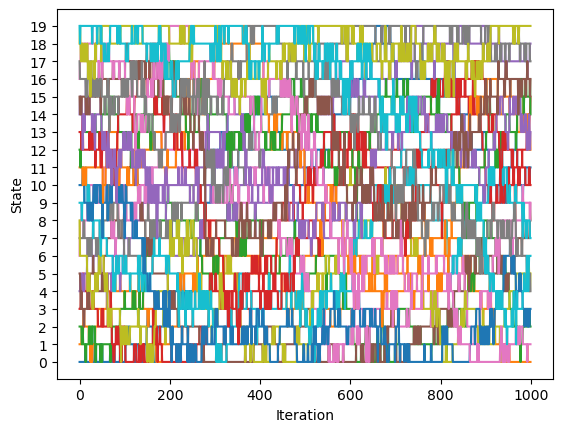

In [7]:
import matplotlib.pyplot as plot
import os

log = np.loadtxt(os.path.join('repex', 'log.csv'), delimiter=',', skiprows=1)
plot.plot(log[:,2:])
plot.xlabel('Iteration')
plot.ylabel('State')
plot.yticks(np.arange(20))
plot.show()

There is good mixing between all states, so they are close enough together to allow frequent exchanges.  If there were not, we would need to increase the number of states.

Let's load the trajectory file for state 0 (temperature 300K) and create a Ramachandran plot for it.

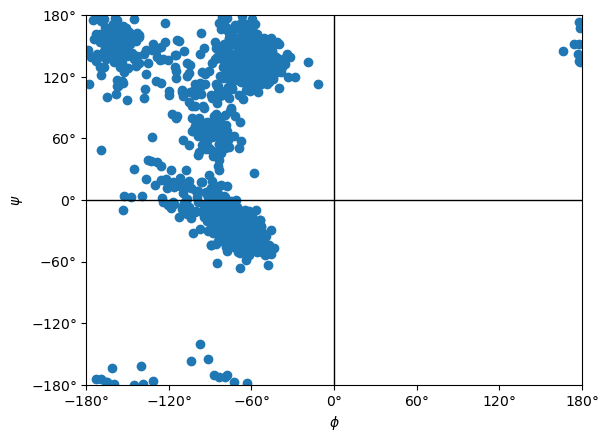

In [9]:
import MDAnalysis as mda
from MDAnalysis.analysis.dihedrals import Ramachandran

u = mda.Universe('alanine-dipeptide.pdb', os.path.join('repex', 'state_0.xtc'))
ramachandran = Ramachandran(u.select_atoms('protein')).run()
ramachandran.plot()
plot.show()

We have a well converged distribution of dihedral angles at our target temperature.

Replica exchange clearly worked, but you might still wonder if it was really worth doing.  We had to simulate 20 replicas, 19 of which were at temperatures we didn't really care about.  If we had just run a single simulation at 300K for 20 times as long, could we have gotten as good a result?

The answer depends on the details of a particular simulation, but often replica exchange still ends up as a huge benefit despite the need to simulate extra replicas.  The reason is that transition rates depend exponentially on $E/k_BT$, where $E$ is the barrier height.  Even a small increase in temperature can sometimes lead to a large increase in the number of transitions observed.  If instead we ran a single simulation at a fixed temperature, the number of transitions would only grow linearly with the length of the simulation.  In the right cases, the exponential improvement from adding higher temperature replicas is far greater than the linear improvement from a longer simulation.

## Next Steps

Replica exchange is not the only multistate sampling method in OpenMM.  The next tutorial discusses expanded ensemble sampling, a related method that can often be more efficient, but requires a little more care to use correctly.

## Links

- API Documentation
  - [ReplicaExchangeSampler](https://docs.openmm.org/development/api-python/generated/openmm.app.replicaexchangesampler.ReplicaExchangeSampler.html)
  - [ReplicaExchangeReporter](https://docs.openmm.org/development/api-python/generated/openmm.app.replicaexchangereporter.ReplicaExchangeReporter.html)